# ML Project with Titanic Dataset
Instructions given for the project is found in the README-file.

In [845]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
from tabulate import tabulate

## Import data and split for training and testing

In [846]:
train_df = pd.read_csv('./data/train.csv')
X = train_df.drop(columns='Survived')
y = train_df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'X_train length: {len(X_train)}')
print(f'X_test length: {len(X_test)}')
print(f'y_train length: {len(y_train)}')
print(f'y_test length: {len(y_test)}')


X_train length: 712
X_test length: 179
y_train length: 712
y_test length: 179


## Exploratory Data Analysis (EDA)

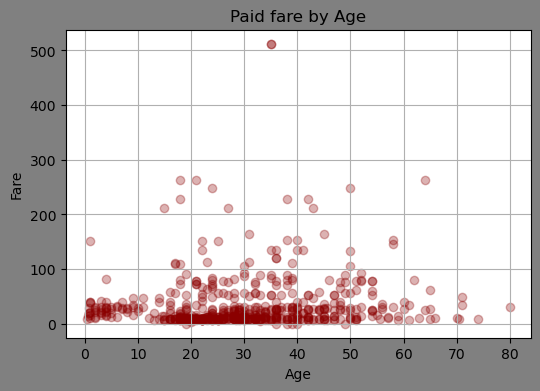

In [847]:
plt.figure(figsize=(6,4), facecolor='gray')
plt.scatter(X_train['Age'], X_train['Fare'], alpha=0.3, color='darkred')
plt.grid(True)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Paid fare by Age')
plt.show()

In [848]:
X_train['Fare'].describe()

count    712.000000
mean      31.819826
std       48.059104
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

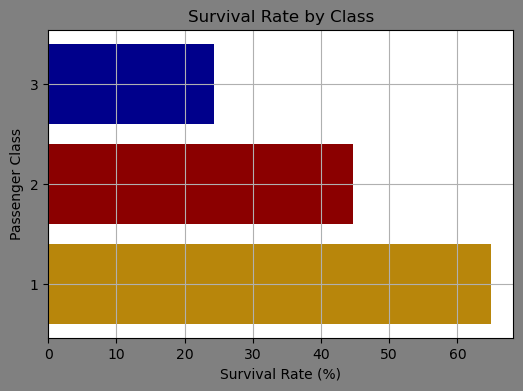

In [849]:
combined_data = X_train.copy()
combined_data['Survived'] = y_train

survival_rate = combined_data.groupby('Pclass')['Survived'].mean() * 100
plt.figure(figsize=(6,4), facecolor='gray')
plt.barh(survival_rate.index, survival_rate.values, color=['darkgoldenrod', 'darkred', 'darkblue'])
plt.grid(True)
plt.xlabel('Survival Rate (%)')
plt.ylabel('Passenger Class')
plt.yticks([1,2,3])
plt.title('Survival Rate by Class')
plt.show()

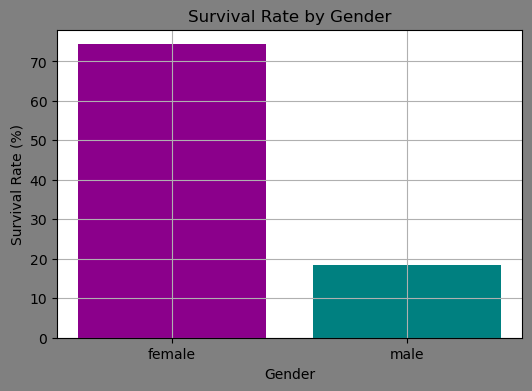

In [850]:
plt.figure(figsize=(6, 4), facecolor='gray')
survival_by_gender = combined_data.groupby('Sex')['Survived'].mean() * 100
plt.bar(survival_by_gender.index, survival_by_gender.values, color=['darkmagenta', 'teal'])
plt.grid(True)
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
plt.title('Survival Rate by Gender')
plt.show()

## Clean the data

A lot of passengers (77%) are missing cabin data. Therefore I decided to get rid of that attribute (column)

In [851]:
X_train = X_train.drop('Cabin', axis=1)
X_test = X_test.drop('Cabin', axis=1)

Check for outliers

In [852]:
print(f"Highest age: {int(X_train['Age'].max())}")

Highest age: 80


Drop columns that are not useful

In [853]:
cols_to_drop = [
    'PassengerId',
    'Name',
    'Ticket'
]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

## Prepare the data

In [854]:
num_pipeline = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler())
cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore', sparse_output=False))

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)
X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

# Create, train, and test models and calculate accuracy

In [855]:
def evaluate_model(model, X_train, y_train):
    predictions = cross_val_predict(model, X_train, y_train, cv=5)
    return {
        'accuracy': accuracy_score(y_train, predictions),
        'precision': precision_score(y_train, predictions),
        'recall': recall_score(y_train, predictions),
        'f1': f1_score(y_train, predictions)        
    }

### Logistic Regression

In [856]:
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train_prepared, y_train)

lr = evaluate_model(lr_clf, X_train_prepared, y_train)

### Decision Tree Classifier

In [857]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_prepared, y_train)

dt = evaluate_model(dt_clf, X_train_prepared, y_train)

### K-Nearest-Neighbors (KNN)

In [858]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_prepared, y_train)

knn = evaluate_model(knn_clf, X_train_prepared, y_train)

### Random Forest

In [859]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_prepared, y_train)

rf = evaluate_model(rf_clf, X_train_prepared, y_train)

### SVC

In [860]:
svc_clf = SVC(C=1.0, gamma='scale', random_state=42)
svc_clf.fit(X_train_prepared, y_train)

svc = evaluate_model(svc_clf, X_train_prepared, y_train)

### Linear SVC

In [861]:
lsvc_clf = LinearSVC(random_state=42, max_iter=10000)
lsvc_clf.fit(X_train_prepared, y_train)

lsvc = evaluate_model(lsvc_clf, X_train_prepared, y_train)


## Print the results

In [862]:
model_mapping = {
    'Logistic Regression': lr_clf,
    'Decision Tree': dt_clf,
    'K Nearest Neighbor': knn_clf,
    'Random Forest': rf_clf,
    'SVC': svc_clf,
    'Linear SVC': lsvc_clf
}

models_data = [
    ['Logistic Regression', round(lr['accuracy']*100, 2), 
        round(lr['precision']*100, 2),  round(lr['recall']*100, 2), round(lr['f1']*100, 2)], 
    ['Decision Tree', round(dt['accuracy']*100, 2), 
        round(dt['precision']*100, 2),  round(dt['recall']*100, 2), round(dt['f1']*100, 2)], 
     ['K Nearest Neighbor', round(knn['accuracy']*100, 2), 
        round(knn['precision']*100, 2),  round(knn['recall']*100, 2), round(knn['f1']*100, 2)], 
    ['Random Forest', round(rf['accuracy']*100, 2), round(rf['precision']*100, 2),
         round(rf['recall']*100, 2), round(rf['f1']*100, 2)],
    ['SVC', round(svc['accuracy']*100, 2), round(svc['precision']*100, 2),
         round(svc['recall']*100, 2), round(svc['f1']*100, 2)],
    ['Linear SVC', round(lsvc['accuracy']*100, 2), round(lsvc['precision']*100, 2),
         round(lsvc['recall']*100, 2), round(lsvc['f1']*100, 2)]
    ]

results = {
    'Logistic Regression': [lr['accuracy'], lr['precision'], lr['recall'], lr['f1']],
    'Decision Tree': [dt['accuracy'], dt['precision'], dt['recall'], dt['f1']],
    'K Nearest Neighbor': [knn['accuracy'], knn['precision'], knn['recall'],  knn['f1']],
    'Random Forest': [rf['accuracy'], rf['precision'], rf['recall'], rf['f1']],
    'SVC': [svc['accuracy'], svc['precision'], svc['recall'], svc['f1']],
    'Linear SVC': [lsvc['accuracy'], lsvc['precision'], lsvc['recall'], lsvc['f1']]

    }

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
best_models = []
for i, metric in enumerate(metrics):
    best_model = max(results.keys(), key=lambda x: results[x][i])
    best_score = results[best_model][i]
    best_models.append(f"{best_model}\n({round(best_score*100, 2)}%)")
    
models_data.append(['BEST MODEL'] + best_models)


print(tabulate(models_data, headers=['MODEL', 'ACCURACY', 'PRECISION', 'RECALL', 'F1'], tablefmt='grid', colalign=['left', 'right', 'right', 'right', 'right']))

+---------------------+------------+-------------+---------------+--------------------+
| MODEL               |   ACCURACY |   PRECISION |        RECALL |                 F1 |
+=====================+============+=============+===============+====================+
| Logistic Regression |      79.78 |       75.29 |         70.33 |              72.73 |
+---------------------+------------+-------------+---------------+--------------------+
| Decision Tree       |      78.23 |       72.01 |          70.7 |              71.35 |
+---------------------+------------+-------------+---------------+--------------------+
| K Nearest Neighbor  |      81.46 |       78.78 |          70.7 |              74.52 |
+---------------------+------------+-------------+---------------+--------------------+
| Random Forest       |      79.63 |       74.62 |         71.06 |               72.8 |
+---------------------+------------+-------------+---------------+--------------------+
| SVC                 |      81.

## Test Set Evaluation

In [863]:
best_accuracy_model = max(results.keys(), key=lambda x: results[x][0])
test_predictions = model_mapping[best_accuracy_model].predict(X_test_prepared)
test_accuracy = accuracy_score(y_test, test_predictions)
print(f'Accuracy for {best_accuracy_model} model on test set: {round(test_accuracy * 100, 2)}%')

Accuracy for SVC model on test set: 81.56%


# Conclusion
I created visualizations showing fare distribution by age and survival rates by class and gender. Survival by gender was surprising to me in that so many more women than men survived. 
Higher class passengers also had better survival rates, likely due to proximity to lifevests/-boats.

After dropping irrelevant columns and the Cabin column (77% missing data), I used preprocessing pipelines to handle missing values and scaling. I tested six different machine learning models and created a comparison table to evaluate their performance across multiple metrics.

Based on the results, I calculated the accuracy for the SVC model on the test set, and I recommend the SVC model for this classification task.